<a href="https://colab.research.google.com/github/giministk/ml/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

In [ ]:
import pandas as pd
import kagglehub
kagglehub.dataset_download('gagandeep16/car-sales')

data = pd.read_csv('/kaggle/input/car-sales/Car_sales.csv')
data.head(10)

Using Colab cache for faster access to the 'car-sales' dataset.


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
5,Audi,A6,18.780,23.555,Passenger,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,8/9/2011,84.565105
6,Audi,A8,1.380,39.000,Passenger,62.00,4.2,310.0,113.0,74.0,198.2,3.902,23.7,21.0,2/27/2012,134.656858
7,BMW,323i,19.747,NaN,Passenger,26.99,2.5,170.0,107.3,68.4,176.0,3.179,16.6,26.0,6/28/2011,71.191207
8,BMW,328i,9.231,28.675,Passenger,33.40,2.8,193.0,107.3,68.5,176.0,3.197,16.6,24.0,1/29/2012,81.877069
9,BMW,528i,17.527,36.125,Passenger,38.90,2.8,193.0,111.4,70.9,188.0,3.472,18.5,25.0,4/4/2011,83.998724


- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Model_Town car,Model_V40,Model_V70,Model_Villager,Model_Viper,Model_Voyager,Model_Windstar,Model_Wrangler,Model_Xterra,Vehicle_type_Passenger
0,16.919,16.360,21.500,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,True
1,39.384,19.875,28.400,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,True
2,14.114,18.225,22.799,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,False,True
3,8.588,29.725,42.000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,...,False,False,False,False,False,False,False,False,False,True
4,20.397,22.255,23.990,1.8,150.0,102.6,68.2,178.0,2.998,16.4,...,False,False,False,False,False,False,False,False,False,True


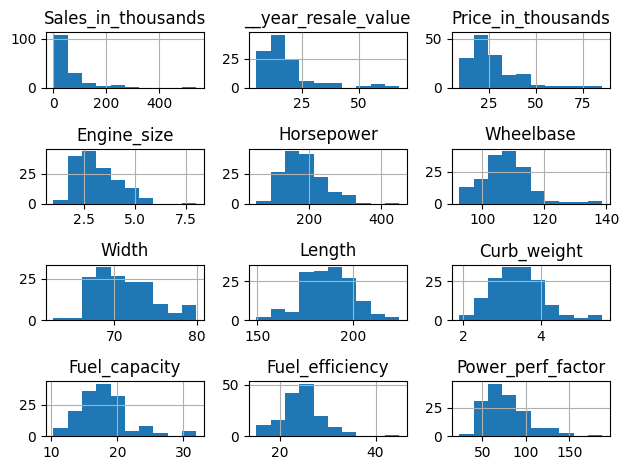

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
float_cols = data.select_dtypes(include='float64')
float_cols.hist()
plt.tight_layout()
data2 = pd.get_dummies(data, columns=['Manufacturer', 'Latest_Launch', 'Model', 'Vehicle_type'], drop_first=True)
data2 = data2.fillna(data2.median())
data2.head()

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

IndexError: index 3 is out of bounds for axis 0 with size 3

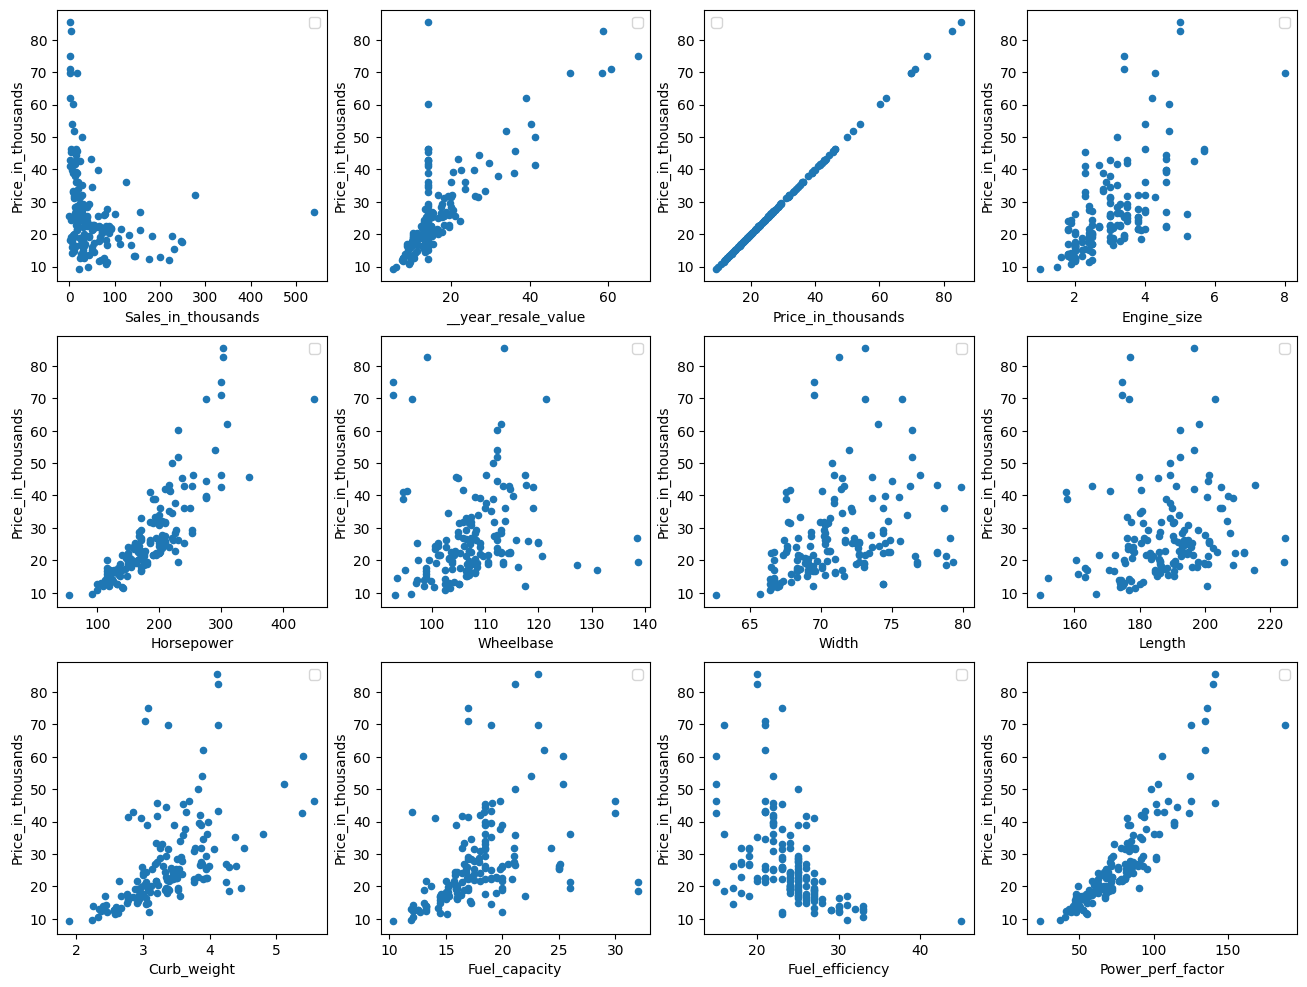

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(data2.columns[:-1]):
     data2.plot(feature, "Price_in_thousands", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

In [ ]:
import seaborn as sns

data2.corr()

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Model_Town car,Model_V40,Model_V70,Model_Villager,Model_Viper,Model_Voyager,Model_Windstar,Model_Wrangler,Model_Xterra,Vehicle_type_Passenger
Sales_in_thousands,1.000000,-0.238623,-0.303049,0.019980,-0.197749,0.358171,0.140897,0.254980,0.008818,0.086520,...,-0.004825,-0.058388,-0.041875,-0.038511,-0.061492,-0.034054,0.121360,0.003021,0.001369,-0.242183
__year_resale_value,-0.238623,1.000000,0.783928,0.462297,0.670061,-0.050220,0.165410,0.037985,0.268868,0.260078,...,0.035863,-0.023676,-0.023676,-0.018823,0.325822,-0.040681,-0.031606,-0.029239,-0.023676,0.085004
Price_in_thousands,-0.303049,0.783928,1.000000,0.626264,0.836720,0.110727,0.329546,0.155968,0.522770,0.423697,...,0.090053,-0.016506,0.008262,-0.027145,0.238634,-0.047748,-0.033337,-0.072459,-0.025518,0.045902
Engine_size,0.019980,0.462297,0.626264,1.000000,0.837347,0.472143,0.690389,0.541400,0.754120,0.663007,...,0.118747,-0.089515,-0.050948,0.018473,0.381002,-0.050948,-0.004667,-0.043234,0.018473,-0.255912
Horsepower,-0.197749,0.670061,0.836720,0.837347,1.000000,0.286345,0.539233,0.393294,0.604644,0.499996,...,0.041359,-0.036798,-0.025429,-0.022587,0.375303,-0.051008,-0.051008,-0.093639,-0.022587,-0.003039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Model_Voyager,-0.034054,-0.040681,-0.047748,-0.050948,-0.051008,0.061329,0.131968,-0.006282,0.019287,0.042542,...,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,1.000000,-0.006410,-0.006410,-0.006410,-0.134671
Model_Windstar,0.121360,-0.031606,-0.033337,-0.004667,-0.051008,0.139363,0.127299,0.081305,0.049161,0.166879,...,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,1.000000,-0.006410,-0.006410,-0.134671
Model_Wrangler,0.003021,-0.029239,-0.072459,-0.043234,-0.093639,-0.148517,-0.103780,-0.212051,-0.042639,0.021819,...,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,1.000000,-0.006410,-0.134671
Model_Xterra,0.001369,-0.023676,-0.025518,0.018473,-0.022587,-0.033576,-0.017417,-0.056074,0.056854,0.030108,...,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,-0.006410,1.000000,-0.134671


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [ ]:
from sklearn.model_selection import train_test_split
X = data2.drop('Price_in_thousands', axis=1)
y = data2['Price_in_thousands']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
display(X_train.shape, X_test.shape)

(109, 325)

(48, 325)

- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np


model = LinearRegression()
model.fit(X_train, y_train)
ridge_mod = Ridge(random_state=42)
lasso_mod = Lasso(random_state=42)
elast_mod = ElasticNet(random_state=42)

param_dist = {'alpha':np.logspace(-4, 4, 50)}
param_dist_elnet = {'alpha':np.logspace(-4, 4, 50), 'l1_ratio':np.linspace(0.001, 0.99, 20)}

grid_search = GridSearchCV(ridge_mod, param_dist, cv=5, n_jobs=-1)
grid_search.fit(X, y)

rsearch_lasso = RandomizedSearchCV(lasso_mod, param_distributions=param_dist,
                                   cv=5, n_jobs=-1, random_state=42)
rsearch_lasso.fit(X, y)

grid_search_elnet = GridSearchCV(elast_mod, param_dist_elnet, cv=5, n_jobs=-1)
grid_search_elnet.fit(X, y)



models = {'LinearRegression': model, 'Ridge': grid_search.best_estimator_, 'Lasso': rsearch_lasso.best_estimator_, 'ElasticNet': grid_search_elnet.best_estimator_}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.342e+02, tolerance: 3.176e+00
  model = cd_fast.enet_coordinate_descent(


- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'RMSE': rmse, 'MAE':mae, 'R²': r2}
    predictions[name] = (y_pred)

    print(f"\n{name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²:   {r2:.4f}")



LinearRegression:
  MSE:  12.3602
  MSE:  12.3602
  MAE: 2.4504
  R²:   0.9569

Ridge:
  MSE:  10.5893
  MSE:  10.5893
  MAE: 2.2816
  R²:   0.9631

Lasso:
  MSE:  10.3597
  MSE:  10.3597
  MAE: 2.3150
  R²:   0.9639

ElasticNet:
  MSE:  9.4827
  MSE:  9.4827
  MAE: 2.1774
  R²:   0.9669


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.001e+02, tolerance: 1.736e+00
  model = cd_fast.enet_coordinate_descent(


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



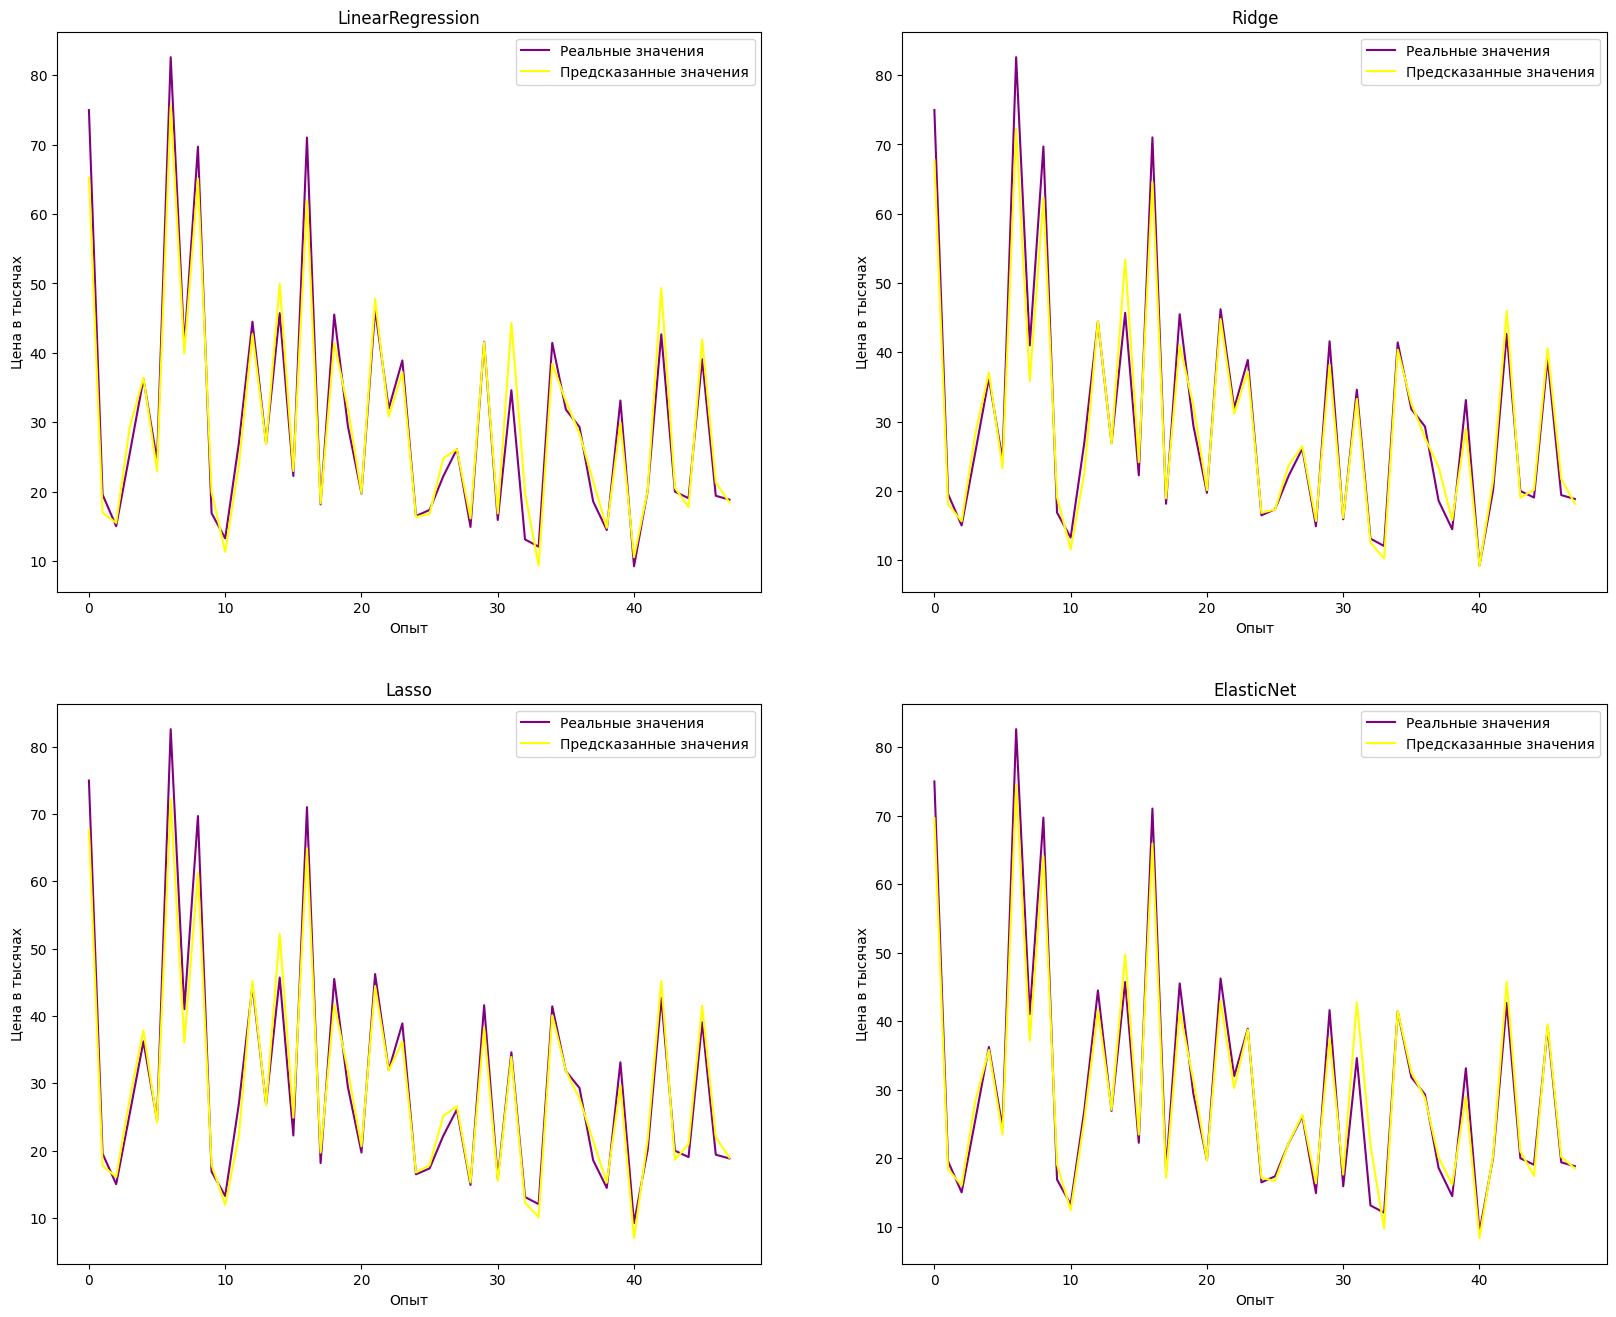

In [ ]:
real = y_test.values

plt.figure(figsize=(20, 16))
n_rows = len(predictions)//2
n_cols = len(predictions) - n_rows

for i, name in enumerate(predictions):
  plt.subplot(n_rows, n_cols, i+1)
  plt.plot(real, label='Реальные значения', color='purple')
  plt.plot(predictions.get(name), label='Предсказанные значения', color='yellow')
  plt.title(name)
  plt.xlabel('Опыт')
  plt.ylabel('Цена в тысячах')
  plt.legend()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [ ]:
df = pd.DataFrame.from_dict(results, orient='index').sort_values('R²',ascending=False)
display(df)
print('лучшая модель', df.iloc[0].name)
print('гиперпараметры', models.get(df.iloc[0].name))

,MSE,RMSE,MAE,R²
ElasticNet,9.482712,3.079401,2.177370,0.966921
Lasso,10.359676,3.218645,2.315018,0.963862
Ridge,10.589277,3.254117,2.281561,0.963061
LinearRegression,12.360245,3.515714,2.450377,0.956883


лучшая модель ElasticNet
гиперпараметры ElasticNet(alpha=np.float64(0.0062505519252739694), l1_ratio=np.float64(0.99),
           random_state=42)


---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [3]:
import kagglehub

kagglehub.dataset_download("waqi786/climate-change-impact-on-agriculture")

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/climate-change-impact-on-agriculture/climate_change_impact_on_agriculture_2024.csv')
print(df.isnull().sum())

Using Colab cache for faster access to the 'climate-change-impact-on-agriculture' dataset.
Year                           0
Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
dtype: int64





- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



In [4]:
display(df.head())
df2 = pd.get_dummies(df, columns=['Country', 'Region', 'Crop_Type', 'Adaptation_Strategies'], drop_first=True)
plt.tight_layout()
df2.corr()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,...,Crop_Type_Fruits,Crop_Type_Rice,Crop_Type_Soybeans,Crop_Type_Sugarcane,Crop_Type_Vegetables,Crop_Type_Wheat,Adaptation_Strategies_Drought-resistant Crops,Adaptation_Strategies_No Adaptation,Adaptation_Strategies_Organic Farming,Adaptation_Strategies_Water Management
Year,1.000000,-0.004583,0.006551,-0.005461,0.010734,-0.002726,0.000938,-0.004332,0.013132,-0.006294,...,-0.017881,0.015268,-0.000976,0.006220,-0.000289,-0.011851,0.012756,0.012525,-0.013854,-0.011001
Average_Temperature_C,-0.004583,1.000000,0.007213,-0.003052,0.263781,-0.016808,-0.013268,0.005764,-0.014725,-0.010841,...,0.011467,-0.005278,0.000926,-0.017441,0.002608,0.017919,0.004855,-0.016139,-0.003266,-0.003744
Total_Precipitation_mm,0.006551,0.007213,1.000000,-0.008681,0.029728,0.004360,-0.007580,0.011198,-0.026356,-0.021621,...,0.021254,-0.002722,0.000084,0.000189,-0.003151,-0.014939,-0.009617,0.005425,-0.000877,-0.003465
CO2_Emissions_MT,-0.005461,-0.003052,-0.008681,1.000000,-0.089868,0.001255,0.002995,0.015243,-0.020275,0.004518,...,0.007112,-0.002376,-0.001947,-0.016438,0.010643,-0.009237,-0.007053,-0.002054,-0.007238,0.017240
Crop_Yield_MT_per_HA,0.010734,0.263781,0.029728,-0.089868,1.000000,-0.005094,-0.000255,-0.004035,0.006423,-0.005692,...,0.017603,0.003080,-0.004348,0.007916,-0.013090,0.009117,0.002204,-0.001049,-0.000909,-0.015577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Crop_Type_Wheat,-0.011851,0.017919,-0.014939,-0.009237,0.009117,0.007428,0.014301,0.014473,-0.008801,0.006248,...,-0.112656,-0.115378,-0.111311,-0.113673,-0.116257,1.000000,-0.017063,-0.012123,0.010023,0.001189
Adaptation_Strategies_Drought-resistant Crops,0.012756,0.004855,-0.009617,-0.007053,0.002204,0.013051,-0.008634,0.000284,0.003155,0.006813,...,0.004791,0.004222,0.000747,0.003760,0.013399,-0.017063,1.000000,-0.251480,-0.247658,-0.253426
Adaptation_Strategies_No Adaptation,0.012525,-0.016139,0.005425,-0.002054,-0.001049,-0.000499,0.008981,-0.005719,-0.005862,0.000330,...,0.013275,0.011624,0.012770,-0.002817,-0.011178,-0.012123,-0.251480,1.000000,-0.249904,-0.255725
Adaptation_Strategies_Organic Farming,-0.013854,-0.003266,-0.000877,-0.007238,-0.000909,-0.002879,0.004861,0.017464,0.000909,0.002329,...,0.001393,-0.004018,-0.003589,-0.011339,0.001970,0.010023,-0.247658,-0.249904,1.000000,-0.251838


<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

KeyError: 'Country_Australia'

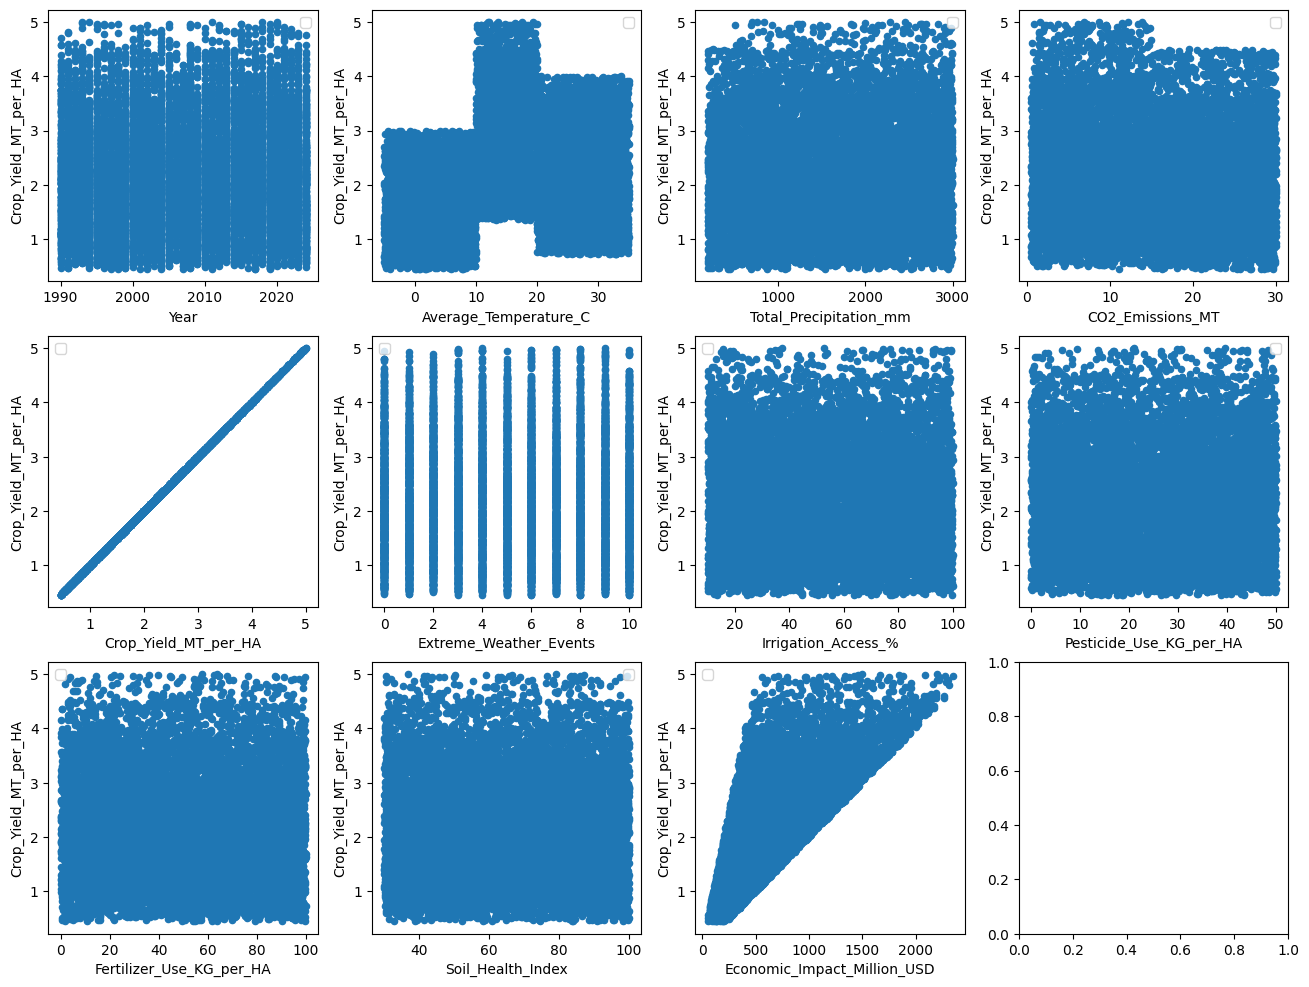

In [5]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df2.columns[:-1]):
     df2.plot(feature, "Crop_Yield_MT_per_HA", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

In [6]:
df3 = df.drop(['Year', 'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index', 'Economic_Impact_Million_USD', 'Crop_Type', 'Adaptation_Strategies', "Country", "Region"], axis=1)

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [7]:
from sklearn.model_selection import train_test_split
X = df3.drop('Crop_Yield_MT_per_HA', axis=1)
y = df3['Crop_Yield_MT_per_HA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
display(X_train.shape, X_test.shape)

(7000, 4)

(3000, 4)



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)
ridge_mod = Ridge(random_state=42)
lasso_mod = Lasso(random_state=42)
elast_mod = ElasticNet(random_state=42)

param_dist = {'alpha':np.logspace(-4, 4, 50)}
param_dist_elnet = {'alpha':np.logspace(-4, 4, 50), 'l1_ratio':np.linspace(0.001, 0.99, 20)}

rsearch_search = RandomizedSearchCV(ridge_mod, param_distributions=param_dist, cv=5, n_jobs=-1, random_state=42)
rsearch_search.fit(X, y)

grid_lasso = GridSearchCV(lasso_mod, param_dist, cv=5, n_jobs=-1)
grid_lasso.fit(X, y)

grid_search_elnet = GridSearchCV(elast_mod, param_dist_elnet, cv=5, n_jobs=-1)
grid_search_elnet.fit(X, y)



models = {'LinearRegression': model, 'Ridge': rsearch_search.best_estimator_, 'Lasso': grid_lasso.best_estimator_, 'ElasticNet': grid_search_elnet.best_estimator_}

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'RMSE': rmse, 'MAE':mae, 'R²': r2}
    predictions[name] = (y_pred)

    print(f"\n{name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²:   {r2:.4f}")


LinearRegression:
  MSE:  0.9484
  MSE:  0.9484
  MAE: 0.7960
  R²:   0.0688

Ridge:
  MSE:  0.9483
  MSE:  0.9483
  MAE: 0.7961
  R²:   0.0689

Lasso:
  MSE:  0.9480
  MSE:  0.9480
  MAE: 0.7960
  R²:   0.0691

ElasticNet:
  MSE:  0.9480
  MSE:  0.9480
  MAE: 0.7960
  R²:   0.0692




- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

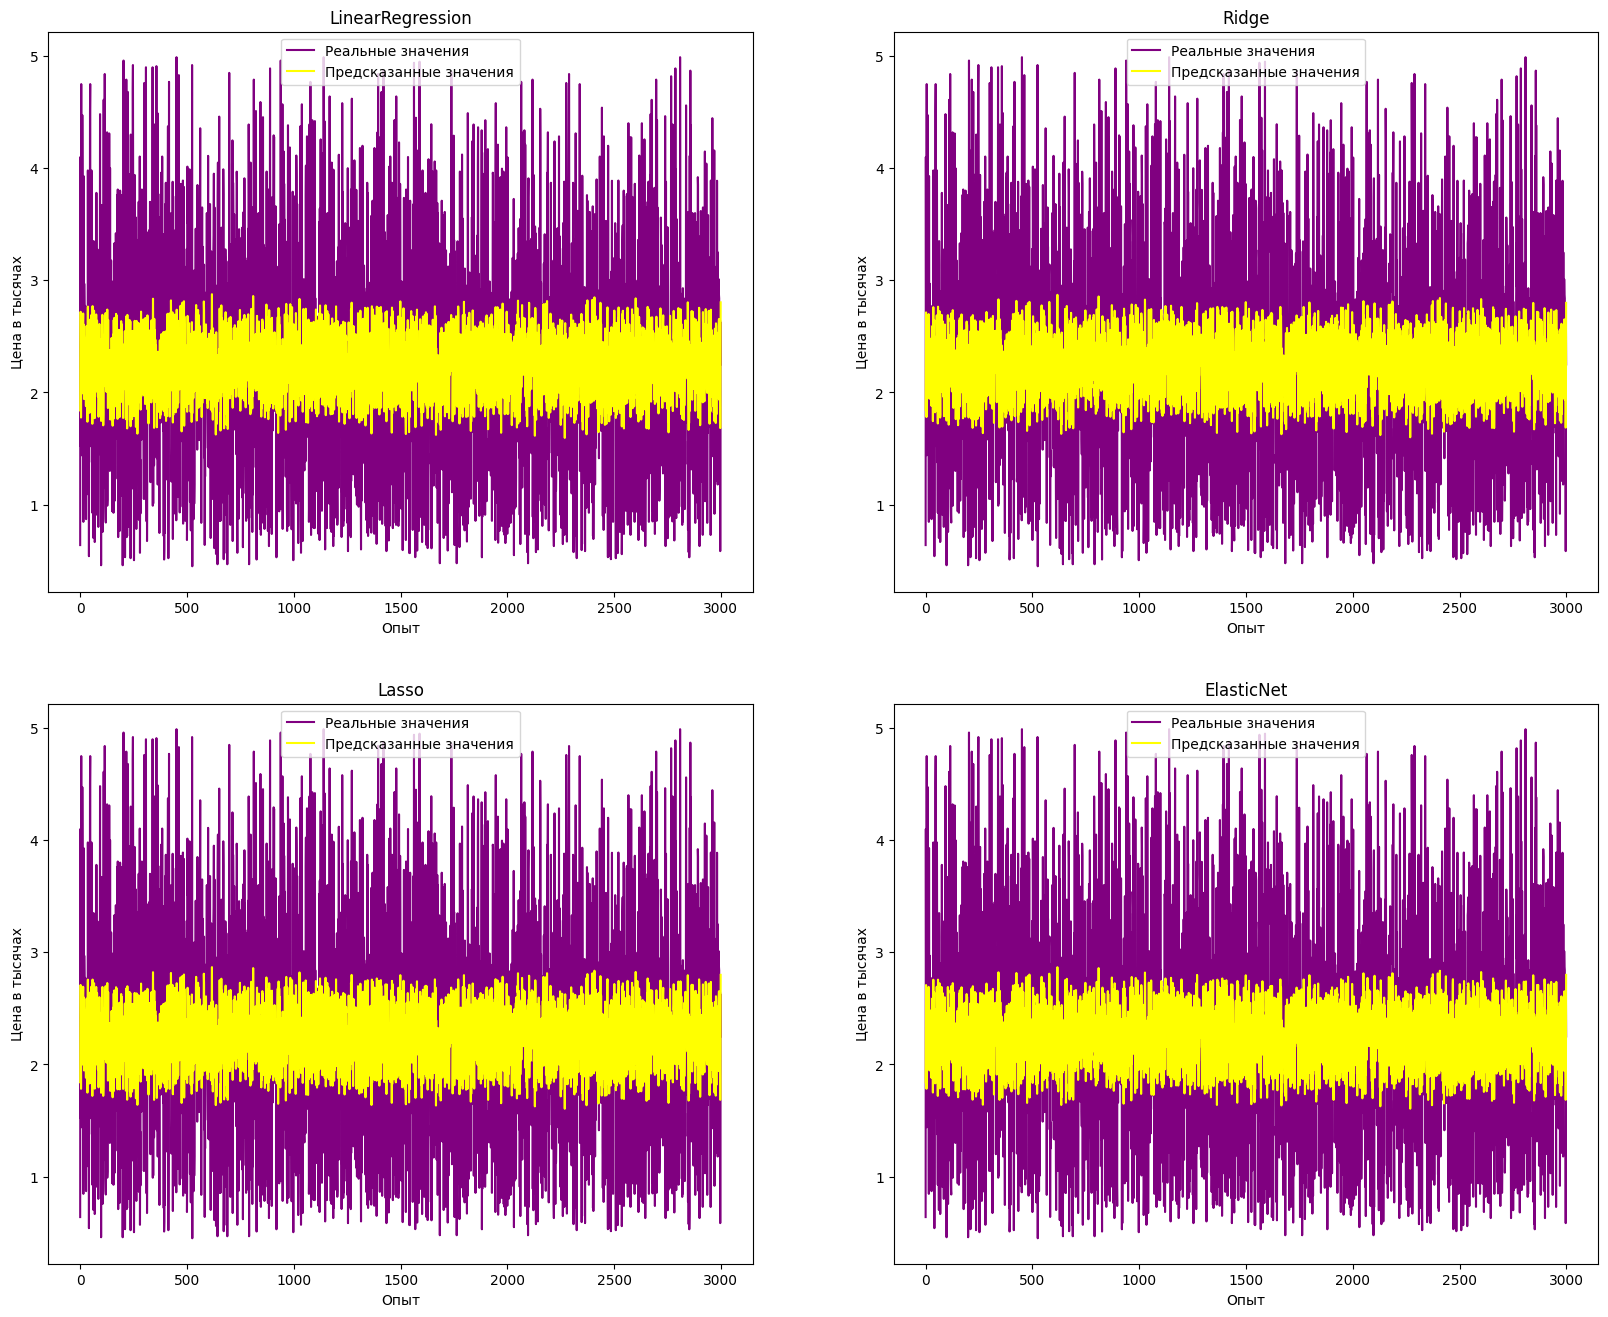

In [10]:
real = y_test.values

plt.figure(figsize=(20, 16))
n_rows = len(predictions)//2
n_cols = len(predictions) - n_rows

for i, name in enumerate(predictions):
  plt.subplot(n_rows, n_cols, i+1)
  plt.plot(real, label='Реальные значения', color='purple')
  plt.plot(predictions.get(name), label='Предсказанные значения', color='yellow')
  plt.title(name)
  plt.xlabel('Опыт')
  plt.ylabel('Цена в тысячах')
  plt.legend()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [15]:
df = pd.DataFrame.from_dict(results, orient='index').sort_values('R²',ascending=False)
display(df)
best_model = models.get(df.iloc[0].name)
print('лучшая модель', df.iloc[0].name)
print('гиперпараметры', best_model)

,MSE,RMSE,MAE,R²
ElasticNet,0.948007,0.973657,0.795994,0.069158
Lasso,0.948028,0.973667,0.795996,0.069137
Ridge,0.948306,0.973810,0.796083,0.068865
LinearRegression,0.948405,0.973861,0.796040,0.068767


лучшая модель ElasticNet
гиперпараметры ElasticNet(alpha=np.float64(0.02811768697974228),
           l1_ratio=np.float64(0.7297368421052632), random_state=42)


- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



ElasticNet(alpha=np.float64(0.02811768697974228),
           l1_ratio=np.float64(0.7297368421052632), random_state=42)
Average_Temperature_C: 0.023247
Total_Precipitation_mm: 0.000034
CO2_Emissions_MT: -0.009265
Extreme_Weather_Events: -0.001795


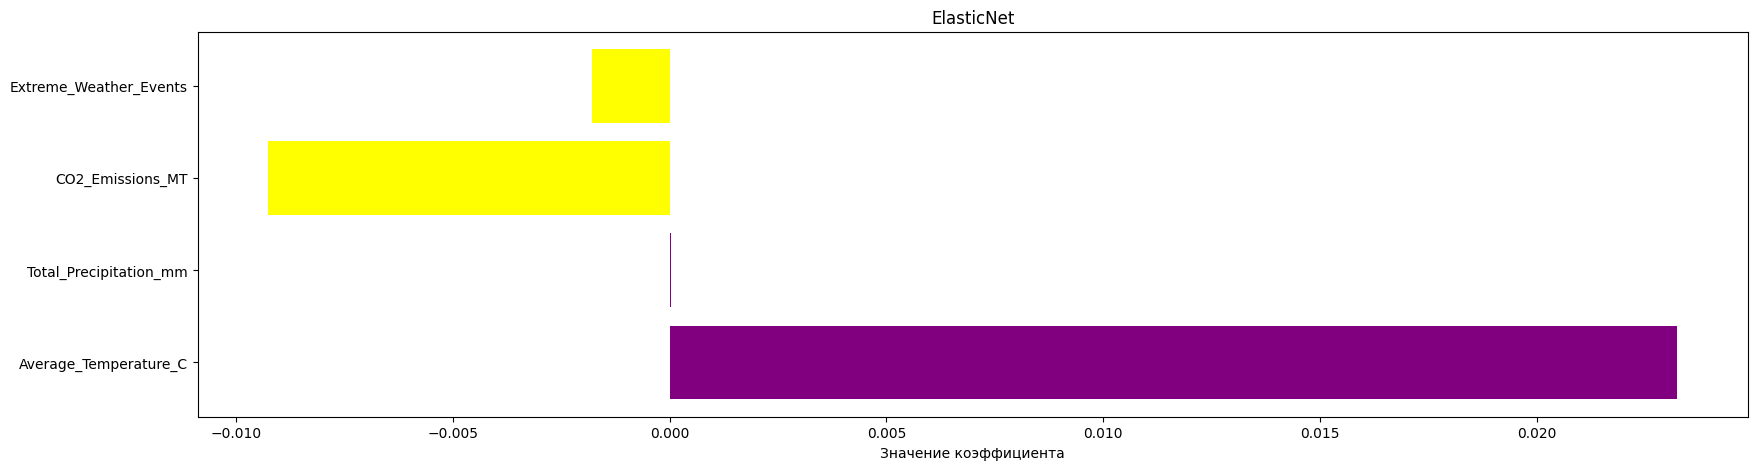

In [19]:
import pandas as pd
coefs = []
cols = []
print(best_model)
for ind, value in enumerate(best_model.coef_):
  print(f"{X_test.columns[ind]}: {value:4f}")
  cols.append(X_test.columns[ind])
  coefs.append(value)

plt.figure(figsize=(20,5))
colors = ['purple' if c > 0 else 'yellow' for c in coefs]
plt.barh(cols, coefs, color=colors)
plt.xlabel('Значение коэффициента')
plt.title(name)
plt.show()

#### **Интерпретация результатов (пример формулировки для отчёта):**


**[ТРЕБУЕТСЯ ЗАПОЛНИТЬ!]**


> На основе анализа коэффициентов лучшей модели установлено, что:
> - **Положительное влияние** на урожайность оказывают: Average_Temperature_C(средняя температура): 0.023247, Total_Precipitation_mm (осадки): 0.000034.
> - **Отрицательное влияние** на урожайность оказывают: CO2_Emissions_MT (выбросы углекислого газа) -0.009265, Extreme_Weather_Events (погодные условия): -0.001795.
> - Наиболее значимым фактором является Average_Temperature_C(средняя температура) с коэффициентом 0.023247, что означает: при увеличении данного показателя на 1 единицу (при прочих равных) урожайность изменяется на 0.023247 единиц.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [57]:
import kagglehub
import pandas as pd

kagglehub.dataset_download("henriqueyamahata/bank-marketing")

df = pd.read_csv('/kaggle/input/bank-marketing/bank-additional-full.csv', sep = ';')
print(df.isnull().sum())
y = df['y']
df = df.drop('y', axis=1)
display(df.head())
df.shape

Using Colab cache for faster access to the 'bank-marketing' dataset.
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


(41188, 20)

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [58]:
from sklearn.preprocessing import StandardScaler

df2 = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome'], drop_first=True)
scaler = StandardScaler().set_output(transform="pandas")

df2.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [59]:
from sklearn.model_selection import train_test_split

y = y.map({'no': 0, 'yes': 1})
X = df2.copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
display(X_train.shape, X_test.shape)

(28831, 53)

(12357, 53)

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np


model_l2 = LogisticRegression(penalty='l2')
model_l1 = LogisticRegression(penalty='l1', solver='saga')
elnet = LogisticRegression(penalty='elasticnet', solver='saga')

c_arr = np.linspace(0.001, 2, 10)
l1_arr = np.linspace(0.001, 0.99, 20)
param_dist = {'C': c_arr}
param_dist_elnet = {'C': c_arr, 'l1_ratio': l1_arr}

gsearch_l2 = GridSearchCV(model_l2, param_dist, cv=5, n_jobs=-1)
gsearch_l2.fit(X, y)
rsearch_l1 = RandomizedSearchCV(model_l1, param_dist, cv=5, n_jobs=-1, random_state=42, n_iter=10)
rsearch_l1.fit(X, y)
gsearch_elnet = RandomizedSearchCV(elnet, param_dist_elnet, cv=5, n_jobs=-1, n_iter=10)
gsearch_elnet.fit(X, y)
models = {'Logistic Regression (L2)': gsearch_l2.best_estimator_, 'Logistic Regression (L1)': rsearch_l1.best_estimator_, 'ElasticNet (L1 + L2)': gsearch_elnet.best_estimator_}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

In [61]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

results = {}
predictions = {}
pred_proba = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'F1': f1,
        'Recall': rec
    }
    predictions[name] = (y_pred)
    pred_proba[name] = (y_pred_proba)

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precison:  {prec:.4f}")
    print(f"  F1: {f1:.4f}")
    print(f"  Recall:   {rec:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression (L2):
  Accuracy:  0.9123
  Precison:  0.6862
  F1: 0.5091
  Recall:   0.4046


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Logistic Regression (L1):
  Accuracy:  0.9069
  Precison:  0.6802
  F1: 0.4396
  Recall:   0.3247

ElasticNet (L1 + L2):
  Accuracy:  0.9071
  Precison:  0.6817
  F1: 0.4405
  Recall:   0.3254


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


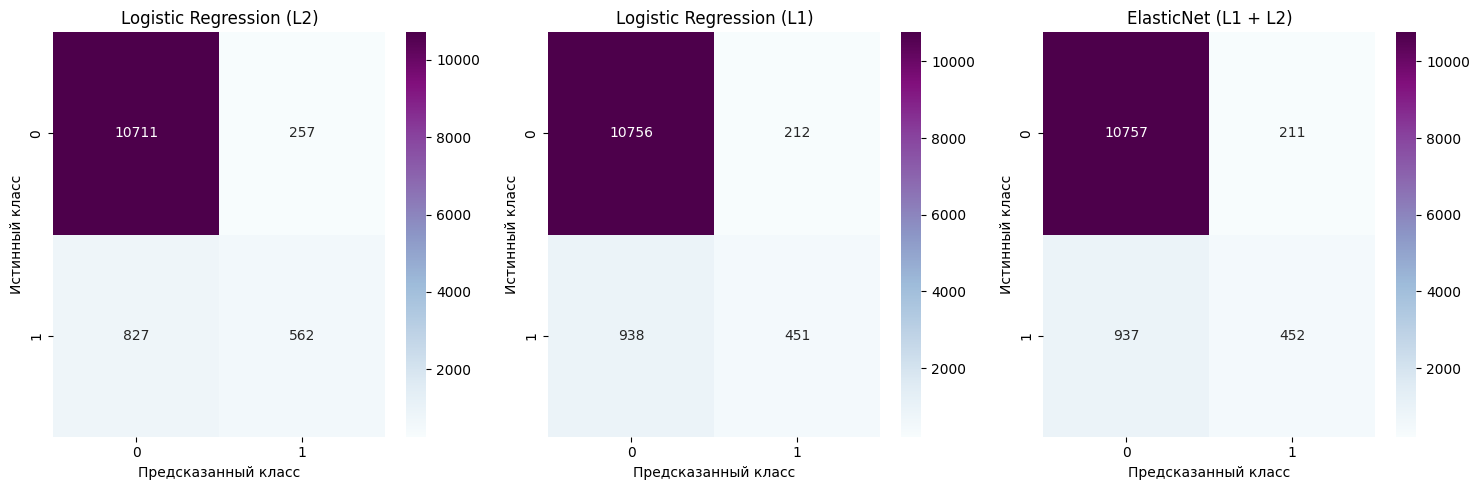

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

real = y_test.values

n_plots = len(predictions)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, name in enumerate(predictions):
    cm = confusion_matrix(y_test, predictions.get(name))
    sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Предсказанный класс')
    axes[i].set_ylabel('Истинный класс')

for i in range(len(predictions), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



AUC (Logistic Regression (L2)): 0.9257
AUC (Logistic Regression (L1)): 0.8808
AUC (ElasticNet (L1 + L2)): 0.8810


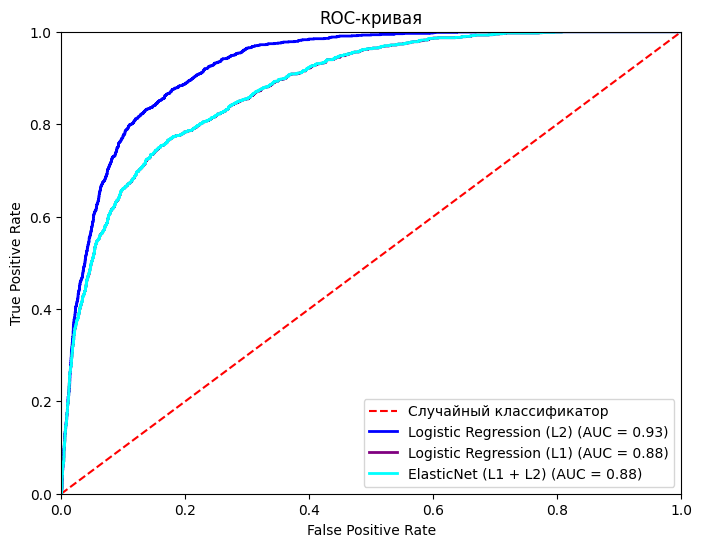

In [63]:
from sklearn.metrics import roc_curve, auc
real = y_test.values
plt.figure(figsize=(8,6))
plt.plot([0,1], [0,1], 'r--', label='Случайный классификатор')

# Список цветов для кривых
colors = ['blue', 'purple', 'cyan', 'magenta']

for ind, name in enumerate(pred_proba):
  fpr, tpr, thresholds = roc_curve(y_test, pred_proba.get(name))
  auc_sc = auc(fpr, tpr)
  print(f'AUC ({name}): {auc_sc:.4f}')

  # Выбираем цвет из списка
  color = colors[ind % len(colors)]
  plt.plot(fpr, tpr, color=color, linewidth=2,
           label=f'{name} (AUC = {auc_sc:.2f})')

plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

,Accuracy,Precision,F1,Recall
Logistic Regression (L2),0.912276,0.686203,0.509058,0.404608
ElasticNet (L1 + L2),0.907097,0.681750,0.440546,0.325414
Logistic Regression (L1),0.906935,0.680241,0.439571,0.324694


Лучшая модель: Logistic Regression (L2)
Гиперпараметры данной модели: LogisticRegression(C=np.float64(0.001))


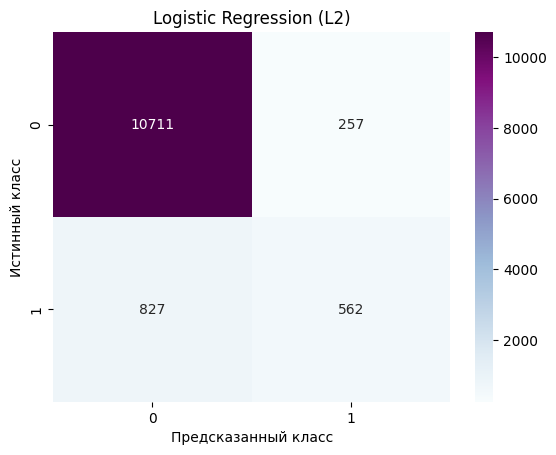

In [64]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame.from_dict(results, orient='index').sort_values('F1',ascending=False)
display(df)
best_model = models.get(df.iloc[0].name)
print(f'Лучшая модель: {df.iloc[0].name}')
print(f'Гиперпараметры данной модели: {best_model}')
cm = confusion_matrix(y_test, predictions.get(df.iloc[0].name))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu')
plt.title(df.iloc[0].name)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()